<a href="https://colab.research.google.com/github/Akshaya24555/CodSoft/blob/main/stock_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this Data Science Project we will create a Linear Regression model and a Decision Tree Regression Model to Predict Apple’s Stock Price using Machine Learning and Python.

**Import pandas to import a CSV file:**



In [ ]:
import pandas as pd
apple=pd.read_csv("/content/AAPL.csv")
print(apple.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100323  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.095089  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.088110  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090291   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092908   73449600


**To get the number of training days:**

In [ ]:
print("trainging days =",apple.shape)

trainging days = (10409, 7)


**To Visualize the close price Data:**

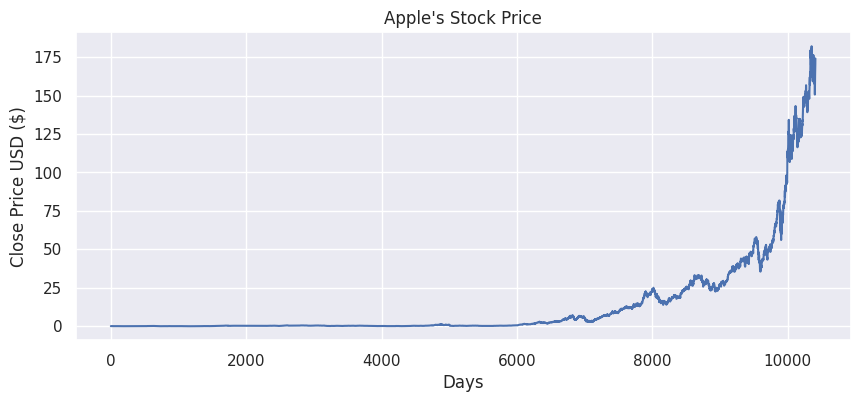

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.figure(figsize=(10, 4))
plt.title("Apple's Stock Price")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(apple["Close"])
plt.show()

**To get the close price:**

In [ ]:
apple = apple[["Close"]].copy()
print(apple.head())

      Close
0  0.128348
1  0.121652
2  0.112723
3  0.115513
4  0.118862


In [ ]:
#Creating a variable to predict ‘X’ days in the future:
futureDays = 5
#Create a new target column shifted ‘X’ units/days up:
apple["Prediction"] = apple[["Close"]].shift(-futureDays)
print(apple.head())
print(apple.tail())

      Close  Prediction
0  0.128348    0.126116
1  0.121652    0.132254
2  0.112723    0.137835
3  0.115513    0.145089
4  0.118862    0.158482
            Close  Prediction
10404  163.979996         NaN
10405  165.380005         NaN
10406  168.820007         NaN
10407  170.210007         NaN
10408  174.070007         NaN


In [ ]:
#To create a feature dataset (x) and convert into a numpy array and remove last ‘x’ rows/days:
import numpy as np
x = np.array(apple["Close"])[:-futureDays]
print(x)

[1.28348000e-01 1.21652000e-01 1.12723000e-01 ... 1.55089996e+02
 1.59589996e+02 1.60619995e+02]


In [ ]:
#To create a target dataset (y) and convert it to a numpy array and get all of the target values except the last ‘x’ rows days:
apple["Prediction"] = apple["Close"].shift(-futureDays)
y = np.array(apple["Prediction"])[:-futureDays]
print(y)

[1.26116000e-01 1.32254000e-01 1.37835000e-01 ... 1.68820007e+02
 1.70210007e+02 1.74070007e+02]


**Split the data into 75% training and 25% testing**

In [ ]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.25)



**Creating Models**

In [ ]:
# Creating the decision tree regressor model
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor().fit(xtrain.reshape(-1, 1), ytrain)
# creating the Linear Regression model
from sklearn.linear_model import LinearRegression
linear = LinearRegression().fit(xtrain.reshape(-1, 1), ytrain)

In [ ]:
#To get the last ‘x’ rows/days of the feature dataset:
xfuture = apple.drop(columns=["Prediction"])[:-futureDays]
xfuture = xfuture.tail(futureDays)
xfuture = np.array(xfuture)
print(xfuture)

[[154.729996]
 [150.619995]
 [155.089996]
 [159.589996]
 [160.619995]]


**To see the model tree prediction**

In [ ]:
treePrediction = tree.predict(xfuture)
print("Decision Tree prediction =",treePrediction)

Decision Tree prediction = [163.979996 165.380005 149.029999 175.839996 160.240005]


**To see the model linear regression prediction**

In [ ]:
linearPrediction = linear.predict(xfuture)
print("Linear regression Prediction =",linearPrediction)

Linear regression Prediction = [155.40316939 151.27570126 155.76469936 160.28382395 161.31820035]


**Visualize decision tree predictions**

/tmp/ipykernel_1417/2779394554.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions


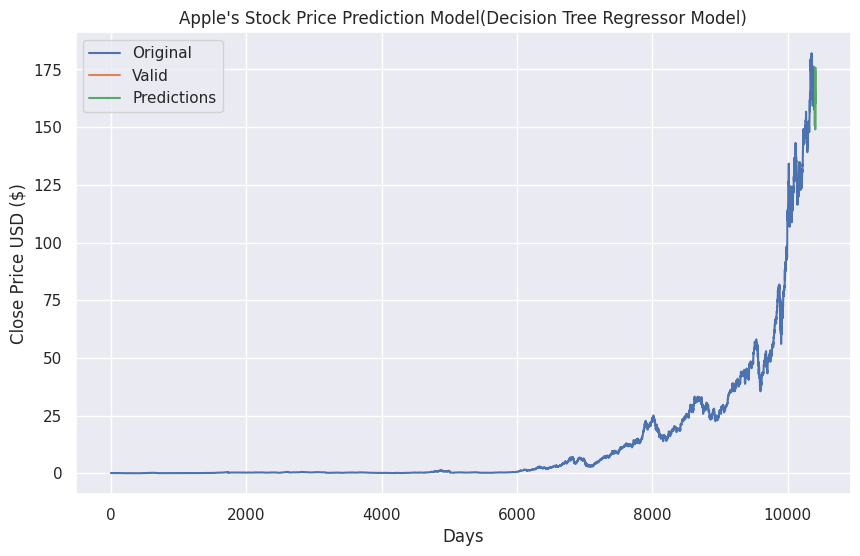

In [ ]:
predictions = treePrediction
valid = apple[x.shape[0]:]
valid["Predictions"] = predictions
plt.figure(figsize=(10, 6))
plt.title("Apple's Stock Price Prediction Model(Decision Tree Regressor Model)")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(apple["Close"])
plt.plot(valid[["Close", "Predictions"]])
plt.legend(["Original", "Valid", "Predictions"])
plt.show()

**Visualize the linear model predictions**

/tmp/ipykernel_1417/93325786.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions


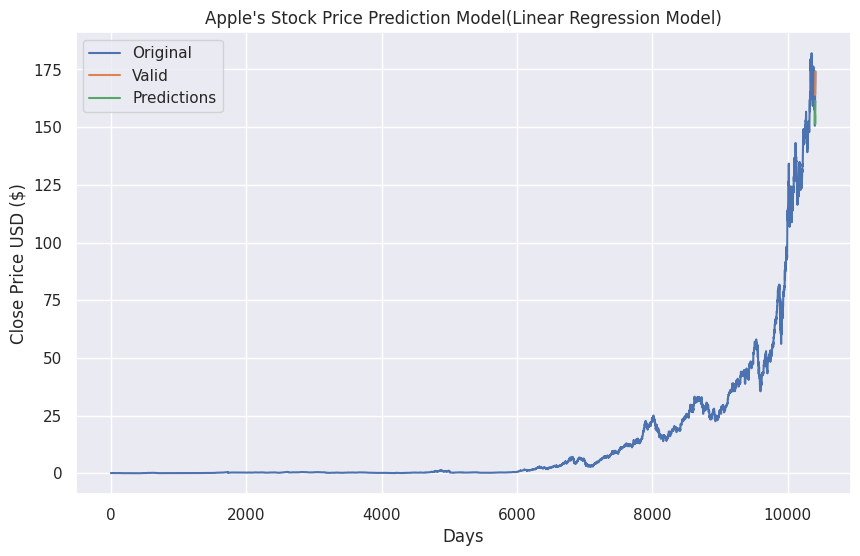

In [ ]:
predictions = linearPrediction
valid = apple[x.shape[0]:]
valid["Predictions"] = predictions
plt.figure(figsize=(10, 6))
plt.title("Apple's Stock Price Prediction Model(Linear Regression Model)")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(apple["Close"])
plt.plot(valid[["Close", "Predictions"]])
plt.legend(["Original", "Valid", "Predictions"])
plt.show()